# D6.1 Review of Oscillatory Motion — From Springs to Resonance
<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D6.1.1 The 1D Spring: Simple Harmonic Motion

We begin with the simplest and most important example of oscillatory motion: a **mass attached to a spring**.

The restoring force is given by **Hooke’s Law**:

$$
F = -kx
$$

Applying Newton’s second law:

$$
m\ddot{x} = -kx
\quad \Rightarrow \quad
\ddot{x} + \frac{k}{m}x = 0
$$

This is the defining equation of **simple harmonic motion (SHM)**.

---

### General Solution

$$
x(t) = A\cos(\omega t + \phi)
$$

where

$$
\omega = \sqrt{\frac{k}{m}}
$$

---

### Physical Interpretation

- $A$ = amplitude  
- $\omega$ = angular frequency  
- $\phi$ = phase  

The motion is:
- periodic  
- bounded  
- symmetric about equilibrium  

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D6.1.2 General Form of SHM

Any system obeying

<div style="background-color:#e7f3ff; padding: 15px; border-left: 6px solid #2196F3;">

<strong>Definition: General Form of Simple Harmonic Motion (SHM)</strong>

$$
\ddot{x} + \omega^2 x = 0
$$

</div>

is undergoing **simple harmonic motion**, regardless of the underlying system.

👉 This is a powerful idea:  
Many systems that are not obviously “springs” still behave like SHM under the right conditions.

---

### Key Properties of SHM

- Motion is sinusoidal  
- Energy oscillates between kinetic and potential  
- The period is constant:

$$
T = \frac{2\pi}{\omega}
$$

---

<div style="background-color:#fff3cd; padding: 15px; border-left: 6px solid #ffecb5;">
<strong>Insight:</strong><br>
The importance of SHM lies not in springs themselves, but in the fact that many systems reduce to this form near equilibrium.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D6.1.3 Damped Oscillations

Real systems experience energy loss due to friction or resistance.

We model this with a **damping force proportional to velocity**:

$$
F_{\text{damp}} = -b\dot{x}
$$

Newton’s second law becomes:

$$
m\ddot{x} + b\dot{x} + kx = 0
$$

---

### Characteristic Equation

Assuming a solution of the form $x(t) = e^{rt}$ leads to:

$$
mr^2 + br + k = 0
$$

The nature of the motion depends on the **discriminant**:

$$
b^2 - 4mk
$$

---

### 1. Underdamped Motion ($b^2 < 4mk$)

The system oscillates with a decaying amplitude:

$$
x(t) = A e^{-\gamma t} \cos(\omega_d t + \phi)
$$

where

$$
\gamma = \frac{b}{2m}, 
\quad
\omega_d = \sqrt{\omega_0^2 - \gamma^2}
$$

**Behavior:**
- Oscillatory motion persists  
- Amplitude decreases exponentially  
- Energy is gradually dissipated  

---

### 2. Critically Damped Motion ($b^2 = 4mk$)

The system returns to equilibrium as quickly as possible **without oscillating**:

$$
x(t) = (A + Bt)e^{-\gamma t}
$$

**Behavior:**
- No oscillation  
- Fastest return to equilibrium  
- Important in systems where overshoot must be avoided (e.g., measuring devices)

---

### 3. Overdamped Motion ($b^2 > 4mk$)

The system returns to equilibrium without oscillating, but more slowly:

$$
x(t) = A e^{r_1 t} + B e^{r_2 t}
$$

where $r_1$ and $r_2$ are real and negative.

**Behavior:**
- No oscillation  
- Slower return than critical damping  
- Motion is a sum of decaying exponentials  

---

<div style="background-color:#fff3cd; padding: 15px; border-left: 6px solid #ffecb5;">
<strong>Insight:</strong><br>
Damping determines whether oscillations occur at all.  
Only the <strong>underdamped case</strong> produces oscillatory motion, while critical and overdamped systems simply relax back to equilibrium.
</div>

---

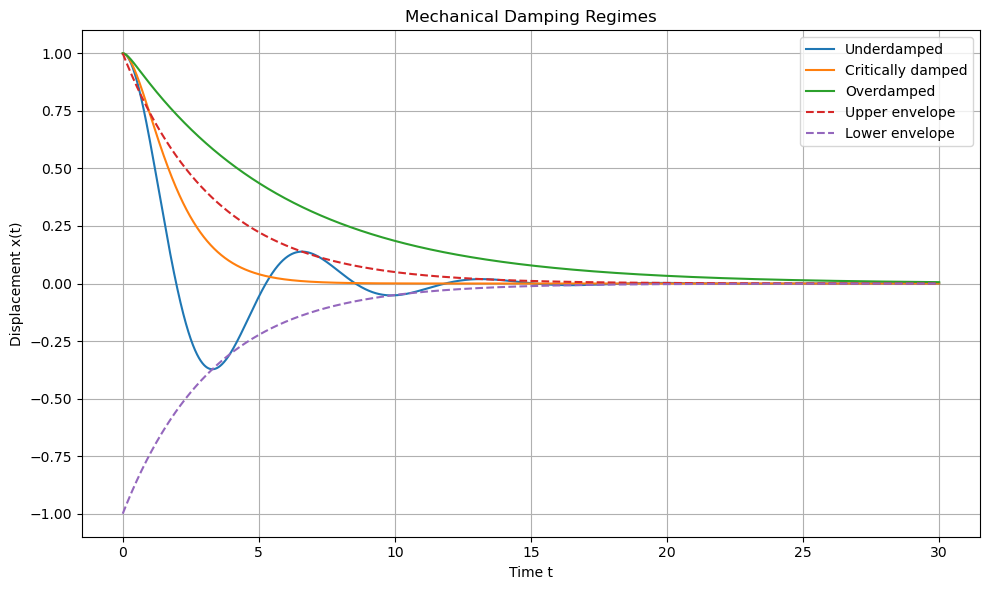

Critical damping coefficient: b_c = 2.0000
Chosen underdamped coefficient: b = 0.6000
Chosen critically damped coefficient: b = 2.0000
Chosen overdamped coefficient: b = 6.0000
Natural angular frequency: omega_0 = 1.0000
Underdamped decay constant: gamma = 0.3000
Underdamped oscillation frequency: omega_d = 0.9539
Underdamped period: T_d = 6.5866


In [2]:
# %reset -f

import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Mechanical damping illustration:
#   1) Underdamped
#   2) Critically damped
#   3) Overdamped
#
# Equation:
#     m x'' + b x' + k x = 0
# ============================================================

# -----------------------------
# Mechanical parameters
# -----------------------------
m = 1.0
k = 1.0

b_critical = 2 * np.sqrt(m * k)

# Better choices:
b_under = 0.3 * b_critical   # clearly oscillatory
b_crit  = 1.0 * b_critical
b_over  = 3.0 * b_critical

# Initial conditions
x0 = 1.0
v0 = 0.0

# Time array
t_max = 30.0
dt = 0.002
t = np.arange(0, t_max + dt, dt)

# -----------------------------
# RHS of first-order system
# -----------------------------
def mech_rhs(state, b, m, k):
    x, v = state
    dxdt = v
    dvdt = -(b / m) * v - (k / m) * x
    return np.array([dxdt, dvdt], dtype=float)

# -----------------------------
# RK4 solver
# -----------------------------
def solve_mechanical(b, m, k, x0, v0, t):
    y = np.zeros((len(t), 2), dtype=float)
    y[0] = [x0, v0]

    for n in range(len(t) - 1):
        h = t[n + 1] - t[n]
        yn = y[n]

        k1 = mech_rhs(yn, b, m, k)
        k2 = mech_rhs(yn + 0.5 * h * k1, b, m, k)
        k3 = mech_rhs(yn + 0.5 * h * k2, b, m, k)
        k4 = mech_rhs(yn + h * k3, b, m, k)

        y[n + 1] = yn + (h / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

    return y[:, 0], y[:, 1]

# -----------------------------
# Solve cases
# -----------------------------
x_under, v_under = solve_mechanical(b_under, m, k, x0, v0, t)
x_crit,  v_crit  = solve_mechanical(b_crit,  m, k, x0, v0, t)
x_over,  v_over  = solve_mechanical(b_over,  m, k, x0, v0, t)

# -----------------------------
# Envelope for underdamped case
# -----------------------------
gamma_under = b_under / (2 * m)
envelope = x0 * np.exp(-gamma_under * t)

# -----------------------------
# Plot: time behavior
# -----------------------------
plt.figure(figsize=(10, 6))
plt.plot(t, x_under, label='Underdamped')
plt.plot(t, x_crit, label='Critically damped')
plt.plot(t, x_over, label='Overdamped')
plt.plot(t, envelope, '--', label='Upper envelope')
plt.plot(t, -envelope, '--', label='Lower envelope')

plt.xlabel('Time t')
plt.ylabel('Displacement x(t)')
plt.title('Mechanical Damping Regimes')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# -----------------------------
# Useful quantities
# -----------------------------
omega0 = np.sqrt(k / m)
gamma = b_under / (2 * m)
omega_d = np.sqrt(omega0**2 - gamma**2)

print(f"Critical damping coefficient: b_c = {b_critical:.4f}")
print(f"Chosen underdamped coefficient: b = {b_under:.4f}")
print(f"Chosen critically damped coefficient: b = {b_crit:.4f}")
print(f"Chosen overdamped coefficient: b = {b_over:.4f}")
print(f"Natural angular frequency: omega_0 = {omega0:.4f}")
print(f"Underdamped decay constant: gamma = {gamma:.4f}")
print(f"Underdamped oscillation frequency: omega_d = {omega_d:.4f}")
print(f"Underdamped period: T_d = {2*np.pi/omega_d:.4f}")

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D6.1.4 Driven (Forced) Oscillations

Now consider an **external driving force**:

$$
F_{\text{drive}} = F_0 \cos(\omega t)
$$

Newton’s second law becomes:

$$
m\ddot{x} + b\dot{x} + kx = F_0 \cos(\omega t)
$$

---

### Steady-State Solution

After transient motion dies out:

$$
x(t) = A(\omega)\cos(\omega t - \delta)
$$

where the amplitude is

$$
A(\omega) =
\frac{F_0/m}
{\sqrt{(\omega_0^2 - \omega^2)^2 + (2\gamma \omega)^2}}
$$

---

### Key Idea

The system oscillates at the **driving frequency**, not its natural frequency.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">


## D6.1.5 Resonance

**Resonance** occurs when the system responds most strongly to the driving force.

- The amplitude becomes **maximal**
- This occurs near the natural frequency $\omega_0$

---

### Physical Picture

- Low $\omega$: system follows the force  
- High $\omega$: system cannot respond quickly  
- Intermediate $\omega \approx \omega_0$: maximum response  

---

### Important Subtlety

With damping, the true resonance frequency is slightly shifted from $\omega_0$.

<hr style="height:2px;border-width:0;color:gray;background-color:gray">

## D6.1.6 The Quality Factor (Q-Factor)

The **quality factor**, or **Q-factor**, measures how lightly damped an oscillator is.

A high-$Q$ oscillator loses only a small fraction of its energy during each cycle, so it continues oscillating for a long time. A low-$Q$ oscillator loses energy quickly, so its oscillations die away rapidly.

---

### Starting Point: The Damped Oscillator

For a damped oscillator,

$$
m\ddot{x} + b\dot{x} + kx = 0.
$$

Dividing by $m$ gives

$$
\ddot{x} + \frac{b}{m}\dot{x} + \frac{k}{m}x = 0.
$$

We define

$$
\omega_0 = \sqrt{\frac{k}{m}},
\qquad
\gamma = \frac{b}{2m}.
$$

Then the equation becomes

$$
\ddot{x} + 2\gamma \dot{x} + \omega_0^2 x = 0.
$$

For weak damping, the underdamped solution is

$$
x(t) = A_0 e^{-\gamma t}\cos(\omega_d t + \phi),
$$

where

$$
\omega_d = \sqrt{\omega_0^2 - \gamma^2}.
$$

For weak damping,

$$
\omega_d \approx \omega_0.
$$

---

### Energy Decay

The amplitude decays as

$$
A(t) = A_0 e^{-\gamma t}.
$$

Since oscillator energy is proportional to amplitude squared,

$$
E \propto A^2,
$$

the energy decays as

$$
E(t) = E_0 e^{-2\gamma t}.
$$

So the fractional rate of energy loss is

$$
\frac{1}{E}\frac{dE}{dt} = -2\gamma.
$$

---

### Energy Lost in One Cycle

For weak damping, one oscillation takes approximately

$$
T = \frac{2\pi}{\omega_0}.
$$

During one cycle, the fractional energy lost is approximately

$$
\frac{\Delta E}{E}
\approx
2\gamma T.
$$

Substituting the period:

$$
\frac{\Delta E}{E}
\approx
2\gamma \left(\frac{2\pi}{\omega_0}\right)
=
\frac{4\pi\gamma}{\omega_0}.
$$

---

### Definition of Q

The Q-factor is defined as

$$
Q = 2\pi \frac{\text{energy stored}}{\text{energy lost per cycle}}.
$$

Using

$$
\frac{\Delta E}{E}
\approx
\frac{4\pi\gamma}{\omega_0},
$$

we get

$$
Q
=
2\pi \frac{E}{\Delta E}
\approx
2\pi
\left(
\frac{1}{4\pi\gamma/\omega_0}
\right).
$$

Therefore,

$$
Q \approx \frac{\omega_0}{2\gamma}.
$$

Since

$$
\gamma = \frac{b}{2m},
$$

we also have

$$
Q = \frac{m\omega_0}{b}.
$$

---

### Interpretation

$$
Q = \frac{\omega_0}{2\gamma}
$$

This tells us that $Q$ compares two timescales:

- $\omega_0$ measures how rapidly the system oscillates  
- $\gamma$ measures how rapidly the amplitude decays  

So:

- **High $Q$** means many oscillations occur before significant energy is lost.  
- **Low $Q$** means energy is lost in only a few cycles.  

---

### Connection to Resonance

The Q-factor also controls the sharpness of resonance.

For a driven oscillator:

- high $Q$ gives a tall, narrow resonance peak  
- low $Q$ gives a shorter, broader resonance peak  

A useful approximation is

$$
Q \approx \frac{\omega_0}{\Delta \omega},
$$

where $\Delta \omega$ is the width of the resonance curve near its peak.

Thus, $Q$ can be interpreted as a measure of how selectively the oscillator responds to driving frequencies.

---

<div style="background-color:#fff3cd; padding: 15px; border-left: 6px solid #ffecb5;">
<strong>Insight:</strong><br>
The Q-factor tells us how many oscillations the system can complete before losing a significant amount of energy.  
High-$Q$ systems are good at storing energy, while low-$Q$ systems are good at dissipating it.
</div>

<hr style="height:2px;border-width:0;color:gray;background-color:gray">